<h1/> Weather Data Insights: A Four-Year Analysis of Yerevan's Climate (2021-2024)" <h1>

*This project aims to analyze and explore the weather patterns in Yerevan from 2021 to 2024 by performing an Exploratory Data Analysis (EDA). The primary objective is to understand the trends, seasonal variations, and extreme weather events over the four years and identify any significant patterns that could highlight the region's changing climate.*

*The dataset used in this analysis contains daily weather data, including temperature, precipitation, wind speed, and weather conditions for each day in the years 2021 through 2024. By using various statistical and visualization techniques, this project investigates the distribution of weather conditions, correlation between weather notions, extreme weather events, weather patterns, etc., across different years.*

*The findings from this analysis will provide valuable insights into how Yerevan's climate has evolved over the past few years, helping to identify potential impacts of climate change, understand seasonal fluctuations, and provide a deeper understanding of the weather patterns in the region.*

In [106]:
import time
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

import seaborn as sns
from scipy.stats import f_oneway

<h2> Data Scrapping <h2>

*The data scraping process involves using Selenium to navigate a weather website and collect historical weather data for specific dates across multiple years.*

*The script dynamically constructs URLs for each day of the year, iterating through all months and days, and retrieving the weather data (temperature, precipitation, wind speed, and weather description) from the corresponding table rows.*

*After scraping, the data is processed to ensure it is correctly structured, with missing or incomplete values filled using forward-fill methods, ensuring consistency across the dataset. The data is then saved to CSV files for each year, allowing for further analysis and visualization.*

In [11]:
chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--window-size=1920x1080")

In [12]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

In [13]:
base_url = "https://www.weather25.com/europe/armenia/yerevan?page=past-weather#day={}&month={}"

In [14]:
def get_element_text(driver, by, value, wait_time=10):
    try:
        element = WebDriverWait(driver, wait_time).until(
            EC.presence_of_element_located((by, value))
        )
        return element.text.strip()
    except Exception:
        return "N/A"

In [15]:
year_map = {0: "2024", 1: "2023", 2: "2022", 3: "2021"}

# Loop through all months (1 to 12)
for month in range(1, 13):
    # Loop through days (handling month lengths appropriately)
    for day in range(1, 32):
        if month == 2 and day > 28:            # February (ignoring leap years here)
            break
        elif month in [4, 6, 9, 11] and day > 30:  # 30-day months
            break
        elif month not in [2, 4, 6, 9, 11] and day > 31:  # 31-day months
            break

        url = base_url.format(day, month)
        driver.get(url)

        try:
            # Wait for the page to load completely
            WebDriverWait(driver, 15).until(
                lambda d: d.execute_script("return document.readyState") == "complete"
            )

            # Scroll to trigger lazy-loading
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(3)  # Allow extra time for all content to load

            # Retrieve the table rows containing previous years’ data
            rows = driver.find_elements(By.CSS_SELECTOR, "table.table tbody tr")

            # If the very first row is for 2025, skip it.
            if rows:
                first_year_text = get_element_text(rows[0], By.CSS_SELECTOR, "td.left-align span.year-link")
                if first_year_text == "2025":
                    rows = rows[1:]

            # Use a counter (year_map) to assign the years 2024 to 2021 to the first four rows
            for idx, row in enumerate(rows):
                if idx in year_map:
                    assigned_year = year_map[idx]
                    temp_max_year = get_element_text(row, By.CSS_SELECTOR, "td.fourteen_day .day-max-temp span[data-temp]")
                    temp_min_year = get_element_text(row, By.CSS_SELECTOR, "td.fourteen_day .day-min-temp span[data-temp]")
                    precipitation_year = get_element_text(row, By.CSS_SELECTOR, "td span[data-length]")
                    wind_speed_year = get_element_text(row, By.CSS_SELECTOR, "td span[data-wind]")
                    # Retrieve the weather description (e.g., Clear, Cloudy)
                    weather_desc = get_element_text(row, By.CSS_SELECTOR, "td.hide.left-align")
                    
                    # Format the date string
                    date_str = f"{assigned_year}-{month:02d}-{day:02d}"
                    
                    # Print the retrieved data
                    print(f"\nDate: {date_str}")
                    print(f"Min Temp: {temp_min_year}°C")
                    print(f"Max Temp: {temp_max_year}°C")
                    print(f"Precipitation: {precipitation_year} mm")
                    print(f"Wind Speed: {wind_speed_year} Km/h")
                    print(f"Weather: {weather_desc}")
                    print("-" * 40)
                    
                    # Write the data to the corresponding CSV file.
                    filename = f"{assigned_year}.csv"
                    file_exists = os.path.isfile(filename)
                    with open(filename, "a", encoding="utf-8") as f:
                        # If the file doesn't exist, write the header first.
                        if not file_exists:
                            f.write("Date,Min Temp,Max Temp,Precipitation,Wind Speed,Weather\n")
                        f.write(f"{date_str},{temp_min_year},{temp_max_year},{precipitation_year},{wind_speed_year},{weather_desc}\n")

        except Exception as e:
            continue


Date: 2024-01-01
Min Temp: 0°C
Max Temp: 6°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Clear
----------------------------------------

Date: 2023-01-01
Min Temp: -1°C
Max Temp: 5°C
Precipitation: 0 mm
Wind Speed: 4 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2022-01-01
Min Temp: -7°C
Max Temp: -1°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Overcast
----------------------------------------

Date: 2021-01-01
Min Temp: -3°C
Max Temp: 1°C
Precipitation: 0 mm
Wind Speed: 2 Km/h
Weather: Clear
----------------------------------------

Date: 2024-01-02
Min Temp: 0°C
Max Temp: 7°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2023-01-02
Min Temp: -1°C
Max Temp: 9°C
Precipitation: 0 mm
Wind Speed: 3 Km/h
Weather: Clear
----------------------------------------

Date: 2022-01-02
Min Temp: -6°C
Max Temp: 0°C
Precipitation: 0.2 mm
Wind Speed: 6 Km/h
Weather: Light snow
----------------------


Date: 2024-01-15
Min Temp: -4°C
Max Temp: 1°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2023-01-15
Min Temp: -5°C
Max Temp: 3°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Cloudy
----------------------------------------

Date: 2022-01-15
Min Temp: -8°C
Max Temp: -1°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Cloudy
----------------------------------------

Date: 2021-01-15
Min Temp: 2°C
Max Temp: 6°C
Precipitation: 1.2 mm
Wind Speed: 6 Km/h
Weather: Patchy light drizzle
----------------------------------------

Date: 2024-01-16
Min Temp: -3°C
Max Temp: 3°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2023-01-16
Min Temp: -7°C
Max Temp: 0°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Overcast
----------------------------------------

Date: 2022-01-16
Min Temp: 2°C
Max Temp: 6°C
Precipitation: 1 mm
Wind Speed: 6 Km/h
Weather: Patchy light dri


Date: 2022-01-29
Min Temp: -7°C
Max Temp: 0°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Light snow
----------------------------------------

Date: 2021-01-29
Min Temp: -4°C
Max Temp: 0°C
Precipitation: 3.2 mm
Wind Speed: 4 Km/h
Weather: Heavy snow
----------------------------------------

Date: 2024-01-30
Min Temp: -7°C
Max Temp: -1°C
Precipitation: 0.2 mm
Wind Speed: 8 Km/h
Weather: Patchy light snow
----------------------------------------

Date: 2023-01-30
Min Temp: 0°C
Max Temp: 6°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Patchy light snow
----------------------------------------

Date: 2022-01-30
Min Temp: -8°C
Max Temp: -2°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Cloudy
----------------------------------------

Date: 2021-01-30
Min Temp: -1°C
Max Temp: 2°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2024-01-31
Min Temp: -11°C
Max Temp: -3°C
Precipitation: 0 mm
Wind Speed: 9 Km/h
Weather: Par


Date: 2024-02-13
Min Temp: 3°C
Max Temp: 9°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Overcast
----------------------------------------

Date: 2023-02-13
Min Temp: -8°C
Max Temp: 1°C
Precipitation: 0 mm
Wind Speed: 8 Km/h
Weather: Clear
----------------------------------------

Date: 2022-02-13
Min Temp: -3°C
Max Temp: 3°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2021-02-13
Min Temp: 3°C
Max Temp: 10°C
Precipitation: 0 mm
Wind Speed: 4 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2024-02-14
Min Temp: 5°C
Max Temp: 12°C
Precipitation: 0.1 mm
Wind Speed: 6 Km/h
Weather: Overcast
----------------------------------------

Date: 2023-02-14
Min Temp: -8°C
Max Temp: 0°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Clear
----------------------------------------

Date: 2022-02-14
Min Temp: -2°C
Max Temp: 3°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Cloudy
-----------------------


Date: 2024-02-27
Min Temp: -2°C
Max Temp: 4°C
Precipitation: 0 mm
Wind Speed: 8 Km/h
Weather: Clear
----------------------------------------

Date: 2023-02-27
Min Temp: 0°C
Max Temp: 11°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Clear
----------------------------------------

Date: 2022-02-27
Min Temp: 2°C
Max Temp: 11°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2021-02-27
Min Temp: 0°C
Max Temp: 7°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2024-02-28
Min Temp: -2°C
Max Temp: 5°C
Precipitation: 0 mm
Wind Speed: 8 Km/h
Weather: Clear
----------------------------------------

Date: 2023-02-28
Min Temp: 0°C
Max Temp: 13°C
Precipitation: 0 mm
Wind Speed: 4 Km/h
Weather: Overcast
----------------------------------------

Date: 2022-02-28
Min Temp: 2°C
Max Temp: 11°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Partly cloudy
---------------------

...


Date: 2024-11-04
Min Temp: 8°C
Max Temp: 13°C
Precipitation: 0.1 mm
Wind Speed: 8 Km/h
Weather: Patchy rain possible
----------------------------------------

Date: 2023-11-04
Min Temp: 11°C
Max Temp: 19°C
Precipitation: 0.3 mm
Wind Speed: 6 Km/h
Weather: Thundery outbreaks possible
----------------------------------------

Date: 2022-11-04
Min Temp: 7°C
Max Temp: 16°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Clear
----------------------------------------

Date: 2021-11-04
Min Temp: 13°C
Max Temp: 20°C
Precipitation: 0 mm
Wind Speed: 9 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2024-11-05
Min Temp: 5°C
Max Temp: 14°C
Precipitation: 0.0 mm
Wind Speed: 23 Km/h
Weather: Clear
----------------------------------------

Date: 2023-11-05
Min Temp: 11°C
Max Temp: 18°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Clear
----------------------------------------

Date: 2022-11-05
Min Temp: 7°C
Max Temp: 16°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather


Date: 2024-11-18
Min Temp: 4°C
Max Temp: 11°C
Precipitation: 0.0 mm
Wind Speed: 6 Km/h
Weather: Overcast
----------------------------------------

Date: 2023-11-18
Min Temp: 8°C
Max Temp: 15°C
Precipitation: 0 mm
Wind Speed: 11 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2022-11-18
Min Temp: 5°C
Max Temp: 13°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2021-11-18
Min Temp: 2°C
Max Temp: 10°C
Precipitation: 0 mm
Wind Speed: 4 Km/h
Weather: Overcast
----------------------------------------

Date: 2024-11-19
Min Temp: 6°C
Max Temp: 12°C
Precipitation: 0.1 mm
Wind Speed: 8 Km/h
Weather: Patchy rain possible
----------------------------------------

Date: 2023-11-19
Min Temp: 9°C
Max Temp: 15°C
Precipitation: 0 mm
Wind Speed: 20 Km/h
Weather: Clear
----------------------------------------

Date: 2022-11-19
Min Temp: 5°C
Max Temp: 14°C
Precipitation: 0 mm
Wind Speed: 6 Km/h
Weather: Clear
----


Date: 2022-12-02
Min Temp: 5°C
Max Temp: 9°C
Precipitation: 0 mm
Wind Speed: 3 Km/h
Weather: Overcast
----------------------------------------

Date: 2021-12-02
Min Temp: 2°C
Max Temp: 7°C
Precipitation: 0 mm
Wind Speed: 10 Km/h
Weather: Clear
----------------------------------------

Date: 2024-12-03
Min Temp: 0°C
Max Temp: 5°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2023-12-03
Min Temp: 3°C
Max Temp: 11°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Clear
----------------------------------------

Date: 2022-12-03
Min Temp: 4°C
Max Temp: 8°C
Precipitation: 0.1 mm
Wind Speed: 5 Km/h
Weather: Patchy rain possible
----------------------------------------

Date: 2021-12-03
Min Temp: 0°C
Max Temp: 5°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Clear
----------------------------------------

Date: 2024-12-04
Min Temp: 0°C
Max Temp: 6°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Clear
------------------------


Date: 2022-12-16
Min Temp: 3°C
Max Temp: 9°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Cloudy
----------------------------------------

Date: 2021-12-16
Min Temp: 0°C
Max Temp: 8°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2024-12-17
Min Temp: -2°C
Max Temp: 3°C
Precipitation: 0.0 mm
Wind Speed: 5 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2023-12-17
Min Temp: 0°C
Max Temp: 9°C
Precipitation: 5.1 mm
Wind Speed: 22 Km/h
Weather: Light rain
----------------------------------------

Date: 2022-12-17
Min Temp: 3°C
Max Temp: 10°C
Precipitation: 0 mm
Wind Speed: 3 Km/h
Weather: Partly cloudy
----------------------------------------

Date: 2021-12-17
Min Temp: 2°C
Max Temp: 6°C
Precipitation: 0.1 mm
Wind Speed: 7 Km/h
Weather: Patchy rain possible
----------------------------------------

Date: 2024-12-18
Min Temp: -2°C
Max Temp: 4°C
Precipitation: 0 mm
Wind Speed: 4 Km/h
Weather: Clear


Date: 2024-12-31
Min Temp: -1°C
Max Temp: 3°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Clear
----------------------------------------

Date: 2023-12-31
Min Temp: 0°C
Max Temp: 6°C
Precipitation: 0 mm
Wind Speed: 5 Km/h
Weather: Overcast
----------------------------------------

Date: 2022-12-31
Min Temp: -1°C
Max Temp: 7°C
Precipitation: 0 mm
Wind Speed: 3 Km/h
Weather: Clear
----------------------------------------

Date: 2021-12-31
Min Temp: -7°C
Max Temp: 0°C
Precipitation: 0 mm
Wind Speed: 7 Km/h
Weather: Overcast
----------------------------------------


In [16]:
driver.quit()

In [32]:
df24 = pd.read_csv("2024.csv")
df23 = pd.read_csv("2023.csv")
df22 = pd.read_csv("2022.csv")
df21 = pd.read_csv("2021.csv")

<h2>Exploratory Data Analysis (EDA)<h2>

In [18]:
df24.info()  #We have ignored that 2024 was a leap year

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Min Temp       365 non-null    int64  
 2   Max Temp       365 non-null    int64  
 3   Precipitation  365 non-null    float64
 4   Wind Speed     365 non-null    int64  
 5   Weather        365 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 17.2+ KB


In [19]:
df23.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Min Temp       365 non-null    int64  
 2   Max Temp       365 non-null    int64  
 3   Precipitation  365 non-null    float64
 4   Wind Speed     365 non-null    int64  
 5   Weather        365 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 17.2+ KB


In [21]:
df22.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           364 non-null    object 
 1   Min Temp       364 non-null    int64  
 2   Max Temp       364 non-null    int64  
 3   Precipitation  364 non-null    float64
 4   Wind Speed     364 non-null    int64  
 5   Weather        364 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 17.2+ KB


In [22]:
df21.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           344 non-null    object 
 1   Min Temp       344 non-null    int64  
 2   Max Temp       344 non-null    int64  
 3   Precipitation  344 non-null    float64
 4   Wind Speed     344 non-null    int64  
 5   Weather        344 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 16.2+ KB


**Note that each dataframe should contain 365 days, as we have ignored that 2024 was a leap year. However, df22 and df21 obviously miss some days. We will handle this by rewriting the data from the line above(ffil) and if the missing row is january first(the sole possible row) we will use the wor below(bfill).**

In [33]:
df21.head()

,Date,Min Temp,Max Temp,Precipitation,Wind Speed,Weather
0,2021-01-01,-3,1,0.0,2,Clear
1,2021-01-02,-6,-1,0.0,3,Overcast
2,2021-01-03,-4,3,0.0,2,Partly cloudy
3,2021-01-04,-3,2,0.0,3,Partly cloudy
4,2021-01-05,-4,0,0.0,4,Cloudy


In [35]:
# Convert 'Date' to datetime and set as index
df21['Date'] = pd.to_datetime(df21['Date'])
df21 = df21.set_index('Date')

# Create a full date range for 2021
full_date_index = pd.date_range(start='2021-01-01', end='2021-12-31', name='Date')

# Reindex the DataFrame to include all dates
df21 = df21.reindex(full_date_index)

# Forward-fill missing values
df21 = df21.ffill()

# Reset index to restore 'Date' as a column
df21 = df21.reset_index()

In [36]:
df21.head()

,Date,Min Temp,Max Temp,Precipitation,Wind Speed,Weather
0,2021-01-01,-3.0,1.0,0.0,2.0,Clear
1,2021-01-02,-6.0,-1.0,0.0,3.0,Overcast
2,2021-01-03,-4.0,3.0,0.0,2.0,Partly cloudy
3,2021-01-04,-3.0,2.0,0.0,3.0,Partly cloudy
4,2021-01-05,-4.0,0.0,0.0,4.0,Cloudy


In [37]:
df21.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           365 non-null    datetime64[ns]
 1   Min Temp       365 non-null    float64       
 2   Max Temp       365 non-null    float64       
 3   Precipitation  365 non-null    float64       
 4   Wind Speed     365 non-null    float64       
 5   Weather        365 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 17.2+ KB


In [44]:
header = ['Min Temp','Max Temp','Precipitation','Wind Speed']


for col in header:
    df21[col] = df21[col].apply(np.int64)

In [45]:
df21.head()

,Date,Min Temp,Max Temp,Precipitation,Wind Speed,Weather
0,2021-01-01,-3,1,0,2,Clear
1,2021-01-02,-6,-1,0,3,Overcast
2,2021-01-03,-4,3,0,2,Partly cloudy
3,2021-01-04,-3,2,0,3,Partly cloudy
4,2021-01-05,-4,0,0,4,Cloudy


In [46]:
# Convert 'Date' to datetime and set as index
df22['Date'] = pd.to_datetime(df22['Date'])
df22 = df22.set_index('Date')

# Create a full date range for 2022
full_date_index = pd.date_range(start='2022-01-01', end='2022-12-31', name='Date')

# Reindex the DataFrame to include all dates
df22 = df22.reindex(full_date_index)

# Forward-fill missing values
df22 = df22.ffill()

# Reset index to restore 'Date' as a column
df22 = df22.reset_index()

In [47]:
for col in header:
    df22[col] = df22[col].apply(np.int64)

In [48]:
df22.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           365 non-null    datetime64[ns]
 1   Min Temp       365 non-null    int64         
 2   Max Temp       365 non-null    int64         
 3   Precipitation  365 non-null    int64         
 4   Wind Speed     365 non-null    int64         
 5   Weather        365 non-null    object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 17.2+ KB


<h2>Data Analysis<h2>

In [113]:
# Convert the 'Date' column to datetime format and then extract only the 'mm-dd'
df21['Date'] = pd.to_datetime(df21['Date']).dt.strftime('%m-%d')
df22['Date'] = pd.to_datetime(df22['Date']).dt.strftime('%m-%d')
df23['Date'] = pd.to_datetime(df23['Date']).dt.strftime('%m-%d')
df24['Date'] = pd.to_datetime(df24['Date']).dt.strftime('%m-%d')

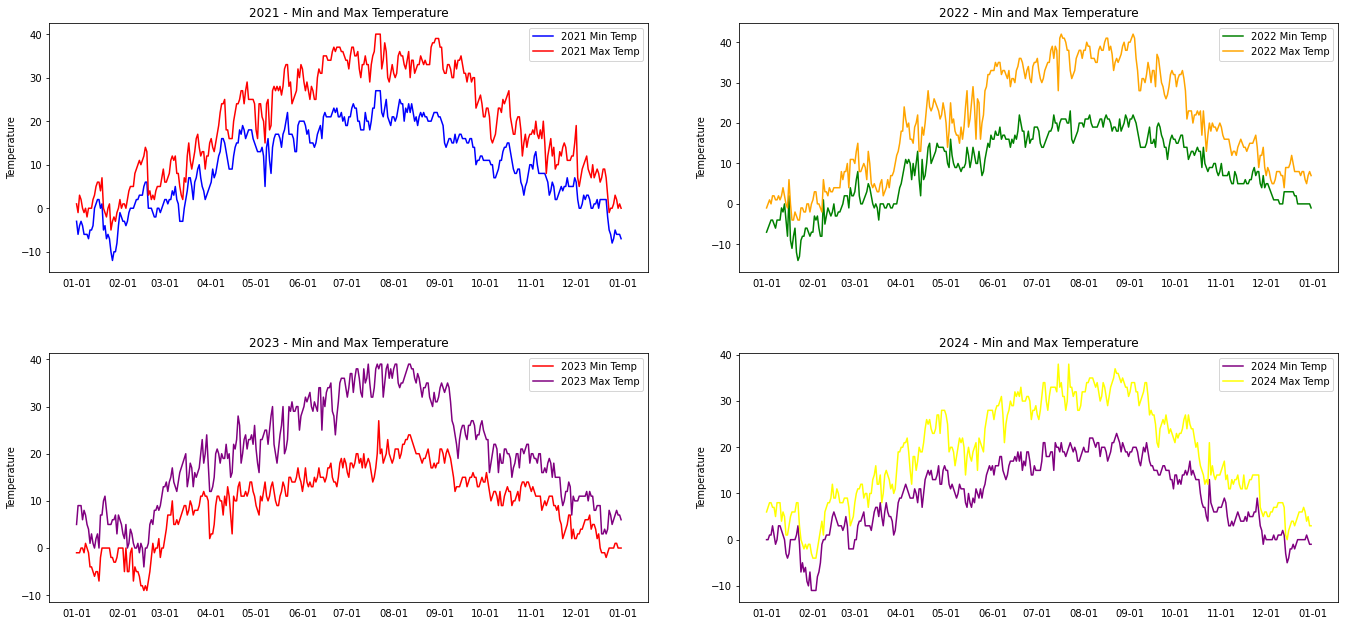

In [52]:
# Create a figure with subplots for each DataFrame
fig, axs = plt.subplots(2, 2, figsize=(20, 10))  # 2x2 grid for 4 subplots
fig.tight_layout(pad=6.0)  # Adjust space between subplots

# Plot for df21
axs[0, 0].plot(df21['Date'], df21['Min Temp'], color='b', label='2021 Min Temp')
axs[0, 0].plot(df21['Date'], df21['Max Temp'], color='r', label='2021 Max Temp')
axs[0, 0].set_title('2021 - Min and Max Temperature')
axs[0, 0].set_ylabel('Temperature')
axs[0, 0].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[0, 0].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[0, 0].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[0, 0].legend()

# Plot for df22
axs[0, 1].plot(df22['Date'], df22['Min Temp'], color='g', label='2022 Min Temp')
axs[0, 1].plot(df22['Date'], df22['Max Temp'], color='orange', label='2022 Max Temp')
axs[0, 1].set_title('2022 - Min and Max Temperature')
axs[0, 1].set_ylabel('Temperature')
axs[0, 1].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[0, 1].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[0, 1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[0, 1].legend()

# Plot for df23
axs[1, 0].plot(df23['Date'], df23['Min Temp'], color='r', label='2023 Min Temp')
axs[1, 0].plot(df23['Date'], df23['Max Temp'], color='purple', label='2023 Max Temp')
axs[1, 0].set_title('2023 - Min and Max Temperature')
axs[1, 0].set_ylabel('Temperature')
axs[1, 0].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[1, 0].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[1, 0].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[1, 0].legend()

# Plot for df24
axs[1, 1].plot(df24['Date'], df24['Min Temp'], color='purple', label='2024 Min Temp')
axs[1, 1].plot(df24['Date'], df24['Max Temp'], color='yellow', label='2024 Max Temp')
axs[1, 1].set_title('2024 - Min and Max Temperature')
axs[1, 1].set_ylabel('Temperature')
axs[1, 1].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[1, 1].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[1, 1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[1, 1].legend()

# Show the plots
plt.show()


In [53]:
weather = set()

# Get unique weather values for each dataframe
unique_weather_df21 = df21['Weather'].unique()
unique_weather_df22 = df22['Weather'].unique()
unique_weather_df23 = df23['Weather'].unique()
unique_weather_df24 = df24['Weather'].unique()

# Print the unique weather values for each dataframe
print(len(unique_weather_df21))
print(len(unique_weather_df22))
print(len(unique_weather_df23))
print(len(unique_weather_df24))

19
23
20
22


In [57]:
# Initialize an empty set to store unique weather types
all_weather_types = set()

# Add the unique weather types from each dataframe to the set
all_weather_types.update(df21['Weather'].unique())
all_weather_types.update(df22['Weather'].unique())
all_weather_types.update(df23['Weather'].unique())
all_weather_types.update(df24['Weather'].unique())

# Print the combined set of all unique weather types
print(all_weather_types)
print(len(all_weather_types))

{'Patchy light rain', 'Thundery outbreaks possible', 'Patchy light rain with thunder', 'Light drizzle', 'Patchy heavy snow', 'Cloudy', 'Patchy light snow', 'Light rain shower', 'Moderate or heavy sleet', 'Light rain', 'Moderate rain', 'Light snow', 'Moderate snow', 'Patchy light drizzle', 'Patchy rain possible', 'Moderate or heavy rain with thunder', 'Light sleet', 'Light snow showers', 'Overcast', 'Light sleet showers', 'Patchy moderate snow', 'Clear', 'Partly cloudy', 'Light freezing rain', 'Moderate or heavy snow showers', 'Moderate rain at times', 'Heavy snow'}
27


In [58]:
weather_order = {'Clear':26,
           'Partly cloudy':25,
           'Cloudy':24,
           'Overcast':23,
           'Patchy light drizzle':22,
           'Light drizzle':21,
           'Patchy rain possible':20,
           'Patchy light rain':19,
           'Light rain':18,
           'Moderate rain at times':17,
           'Moderate rain':16,
           'Thundery outbreaks possible':15,
           'Patchy light rain with thunder':14,
           'Light rain shower':13,
           'Moderate or heavy rain with thunder':12,
           'Light sleet':11,
           'Light sleet showers':10,
           'Moderate or heavy sleet':9,
           'Light freezing rain':8,
           'Light snow':7,
           'Patchy light snow':6,
           'Light snow showers':5,
           'Patchy moderate snow':4,
           'Moderate snow':3,
           'Patchy heavy snow':2,
           'Moderate or heavy snow showers':1,
           'Heavy snow':0}

In [59]:
df21['Weather'] = df21['Weather'].map(weather_order)
df22['Weather'] = df22['Weather'].map(weather_order)
df23['Weather'] = df23['Weather'].map(weather_order)
df24['Weather'] = df24['Weather'].map(weather_order)

# Check the changes for one of the dataframes
print(df21[['Weather']].head())

   Weather
0       26
1       23
2       25
3       25
4       24


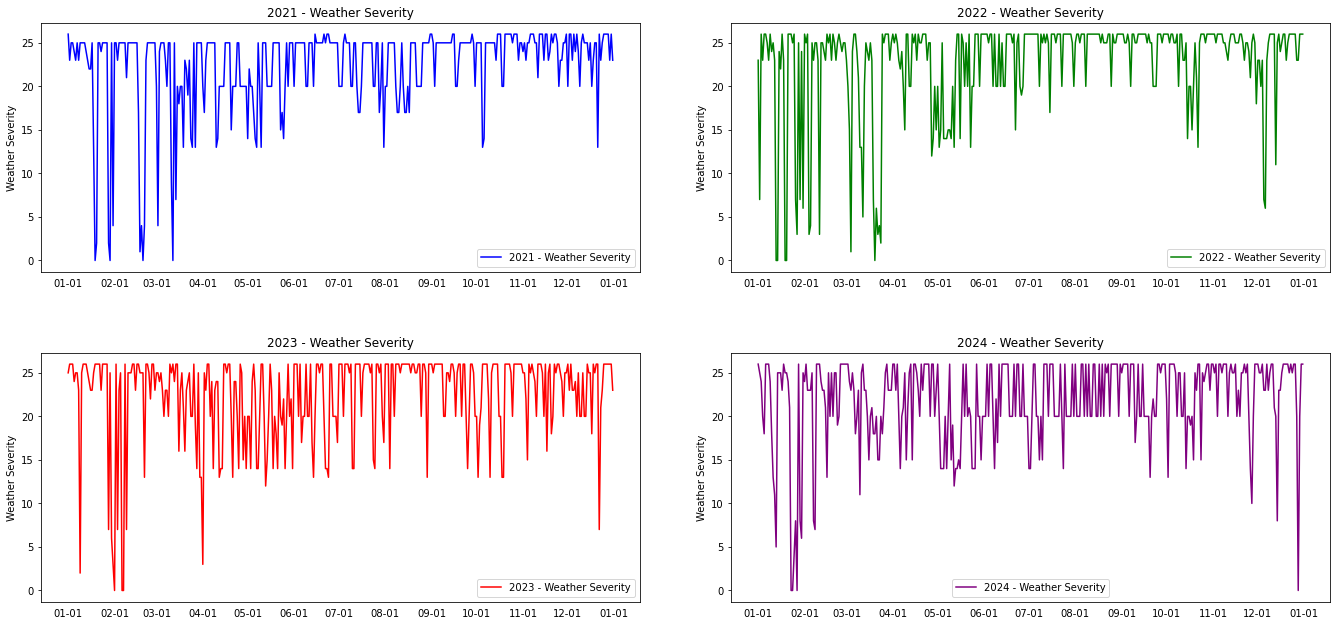

In [61]:
# Create a figure with subplots for each DataFrame
fig, axs = plt.subplots(2, 2, figsize=(20, 10))  # 2x2 grid for 4 subplots
fig.tight_layout(pad=6.0)  # Adjust space between subplots

# Plot for df21 - Weather Severity
axs[0, 0].plot(df21['Date'], df21['Weather'], color='b', label='2021 - Weather Severity')
axs[0, 0].set_title('2021 - Weather Severity')
axs[0, 0].set_ylabel('Weather Severity')

# Set x-axis to display nothing or only each trimester (3 months interval)
axs[0, 0].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[0, 0].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[0, 0].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[0, 0].legend()

# Plot for df22 - Weather Severity
axs[0, 1].plot(df22['Date'], df22['Weather'], color='g', label='2022 - Weather Severity')
axs[0, 1].set_title('2022 - Weather Severity')
axs[0, 1].set_ylabel('Weather Severity')

# Set x-axis to display nothing or only each trimester (3 months interval)
axs[0, 1].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[0, 1].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[0, 1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[0, 1].legend()

# Plot for df23 - Weather Severity
axs[1, 0].plot(df23['Date'], df23['Weather'], color='r', label='2023 - Weather Severity')
axs[1, 0].set_title('2023 - Weather Severity')
axs[1, 0].set_ylabel('Weather Severity')

# Set x-axis to display nothing or only each trimester (3 months interval)
axs[1, 0].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[1, 0].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[1, 0].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[1, 0].legend()

# Plot for df24 - Weather Severity
axs[1, 1].plot(df24['Date'], df24['Weather'], color='purple', label='2024 - Weather Severity')
axs[1, 1].set_title('2024 - Weather Severity')
axs[1, 1].set_ylabel('Weather Severity')

# Set x-axis to display nothing or only each trimester (3 months interval)
axs[1, 1].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide x-axis ticks completely
axs[1, 1].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks every month
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd for clarity
axs[1, 1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=1))  # Optional: Minor ticks for each trimester
axs[1, 1].legend()

# Show the plots
plt.show()

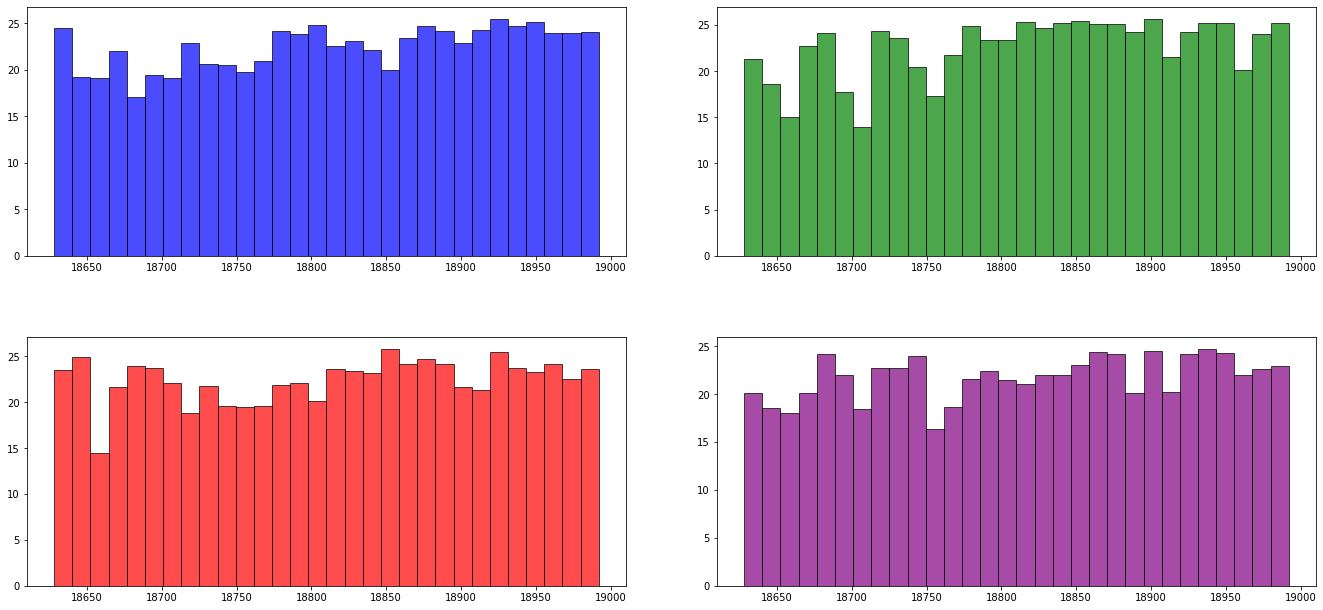

In [80]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))
fig.tight_layout(pad=6.0)

def plot_weather_histogram(ax, df, year, color):
    # Convert dates to numeric values for binning
    dates_num = mdates.date2num(df['Date'])
    weather_values = df['Weather']
    
    # Create 30 evenly spaced bins between the min and max dates
    bin_edges = np.linspace(dates_num.min(), dates_num.max(), 31)
    
    # Calculate sum of weather values and counts in each bin
    sums, _ = np.histogram(dates_num, bins=bin_edges, weights=weather_values)
    counts, _ = np.histogram(dates_num, bins=bin_edges)
    
    # Compute mean values with proper type handling
    means = np.zeros_like(sums, dtype=float)  # Force float type
    np.divide(sums, counts, out=means, where=counts != 0)
    
    # Calculate bin widths (in days)
    bin_widths = np.diff(bin_edges)
    
    # Plot bars representing the mean values
    ax.bar(
        bin_edges[:-1],
        means,
        width=bin_widths,
        color=color,
        edgecolor='black',
        alpha=0.7,
        align='edge'
    )
    
    # Rest of the formatting remains the same...
    
    
plot_weather_histogram(axs[0, 0], df21, "2021", 'b')
plot_weather_histogram(axs[0, 1], df22, "2022", 'g')
plot_weather_histogram(axs[1, 0], df23, "2023", 'r')
plot_weather_histogram(axs[1, 1], df24, "2024", 'purple')

plt.show()

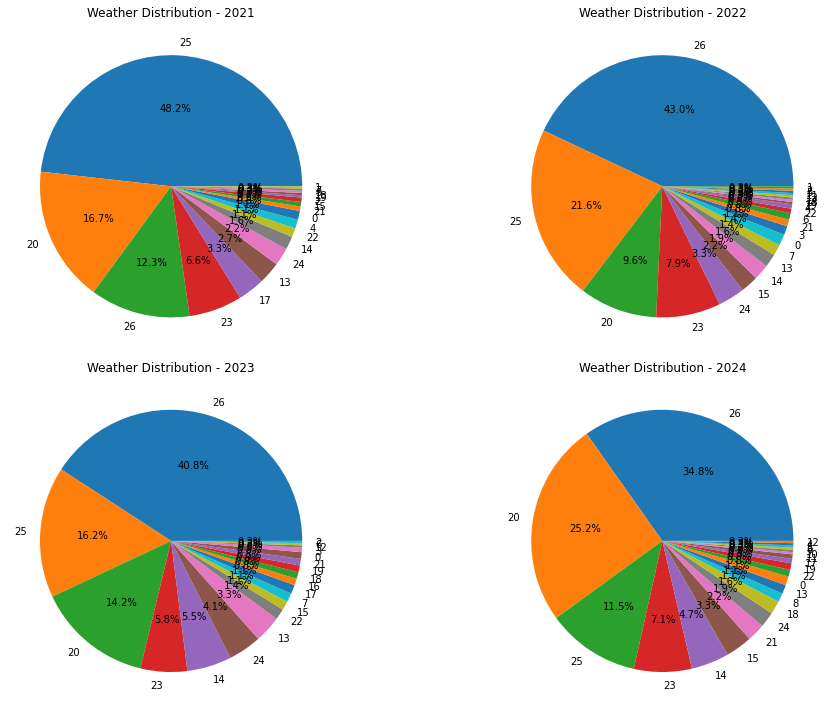

In [70]:
# Count the occurrences of each weather severity level for each year
weather_counts_21 = df21['Weather'].value_counts()
weather_counts_22 = df22['Weather'].value_counts()
weather_counts_23 = df23['Weather'].value_counts()
weather_counts_24 = df24['Weather'].value_counts()

# Create a figure with subplots for each year's pie chart
fig, axs = plt.subplots(2, 2, figsize=(16, 10))  # 2x2 grid for 4 subplots

# Define a function to plot the pie chart
def plot_pie(ax, data, year):
    ax.pie(data, labels=data.index, autopct='%1.1f%%')
    ax.set_title(f'Weather Distribution - {year}')

# Plot pie charts for each year
plot_pie(axs[0, 0], weather_counts_21, "2021")
plot_pie(axs[0, 1], weather_counts_22, "2022")
plot_pie(axs[1, 0], weather_counts_23, "2023")
plot_pie(axs[1, 1], weather_counts_24, "2024")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


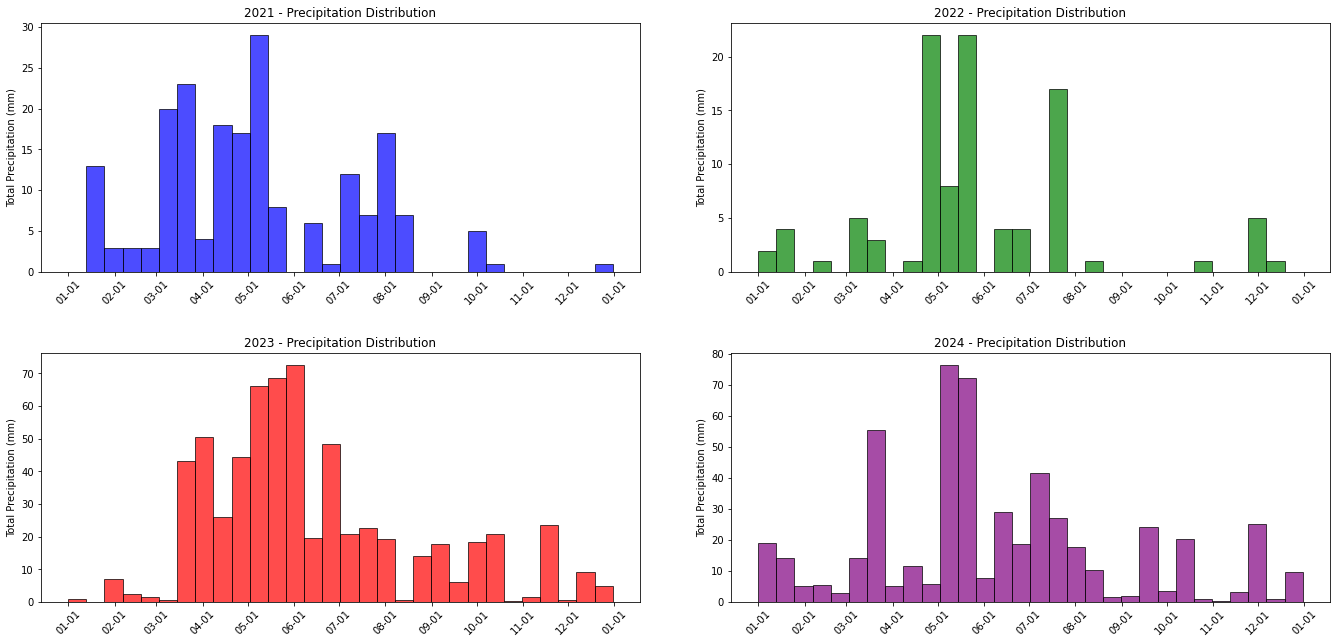

In [73]:
# Create a figure with subplots for each year
fig, axs = plt.subplots(2, 2, figsize=(20, 10))  # 2x2 grid for 4 histograms
fig.tight_layout(pad=6.0)  # Adjust space between subplots

# Function to plot histogram of precipitation
def plot_precipitation_histogram(ax, df, year, color):
    ax.hist(df['Date'], weights=df['Precipitation'], bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'{year} - Precipitation Distribution')
    ax.set_ylabel('Total Precipitation (mm)')

    # Format x-axis to show the first of each month
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))  # Major ticks on 1st of each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # Format as mm-dd
    ax.tick_params(axis='x', rotation=45)  # Rotate labels for readability

# Plot histograms for each year
plot_precipitation_histogram(axs[0, 0], df21, "2021", 'b')
plot_precipitation_histogram(axs[0, 1], df22, "2022", 'g')
plot_precipitation_histogram(axs[1, 0], df23, "2023", 'r')
plot_precipitation_histogram(axs[1, 1], df24, "2024", 'purple')

# Show the histograms
plt.show()


In [92]:
# Function to calculate summary statistics for each year
def descriptive_stats(df):
    stats = df[['Min Temp', 'Max Temp', 'Precipitation', 'Wind Speed']].describe()
    mode_values = df[['Min Temp', 'Max Temp', 'Precipitation', 'Wind Speed']].mode().iloc[0]
    return stats, mode_values

# Apply the function to each year
stats_21, mode_21 = descriptive_stats(df21)
stats_22, mode_22 = descriptive_stats(df22)
stats_23, mode_23 = descriptive_stats(df23)
stats_24, mode_24 = descriptive_stats(df24)

# Display the results for each year
stats_21, mode_21, stats_22, mode_22, stats_23, mode_23, stats_24, mode_24

(         Min Temp    Max Temp  Precipitation  Wind Speed
 count  365.000000  365.000000     365.000000  365.000000
 mean    10.139726   19.663014       0.542466   11.501370
 std      9.202226   12.130874       1.610910    6.323089
 min    -12.000000   -5.000000       0.000000    2.000000
 25%      2.000000    9.000000       0.000000    6.000000
 50%     11.000000   20.000000       0.000000   10.000000
 75%     18.000000   31.000000       0.000000   16.000000
 max     27.000000   40.000000      12.000000   34.000000,
 Min Temp          2.0
 Max Temp         33.0
 Precipitation     0.0
 Wind Speed        6.0
 Name: 0, dtype: float64,
          Min Temp    Max Temp  Precipitation  Wind Speed
 count  365.000000  365.000000     365.000000  365.000000
 mean     8.890411   19.956164       0.276712   12.449315
 std      8.659559   13.067796       1.347619    7.329436
 min    -14.000000   -4.000000       0.000000    3.000000
 25%      2.000000    8.000000       0.000000    7.000000
 50%     10

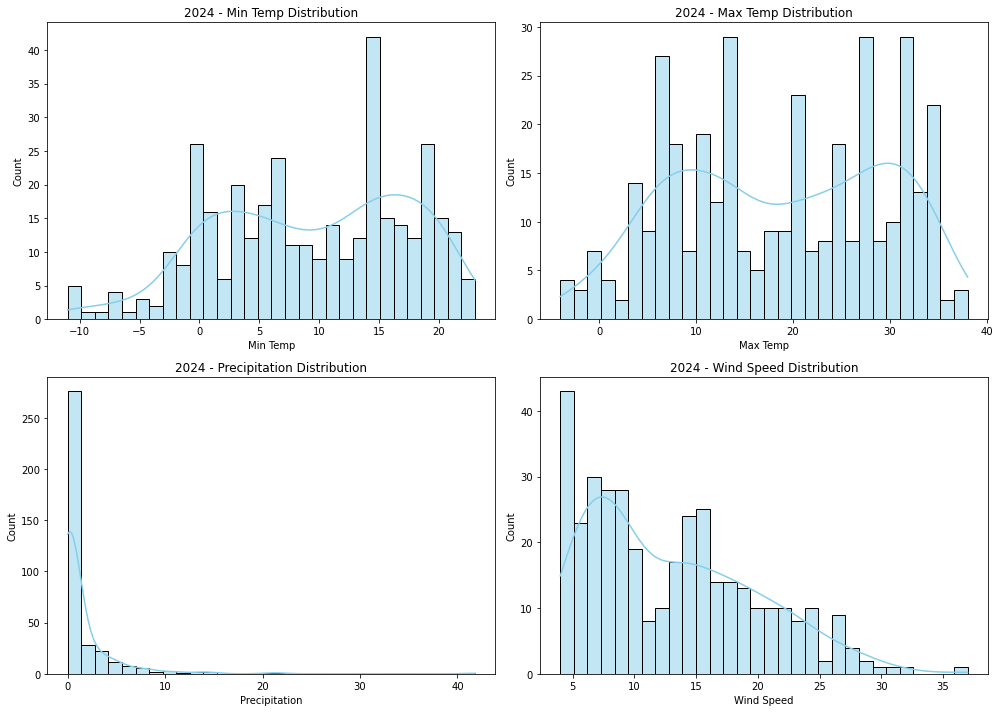

In [96]:
# Visualizing distributions for each year
def plot_distributions(df, year):
    plt.figure(figsize=(14, 10))
    for i, column in enumerate(['Min Temp', 'Max Temp', 'Precipitation', 'Wind Speed'], 1):
        plt.subplot(2, 2, i)
        sns.histplot(df[column], kde=True, bins=30, color='skyblue', edgecolor='black')
        plt.title(f'{year} - {column} Distribution')

    plt.tight_layout()
    plt.show()

# Plot distributions for each year
# plot_distributions(df21, 2021)
# plot_distributions(df22, 2022)
# plot_distributions(df23, 2023)
plot_distributions(df24, 2024)

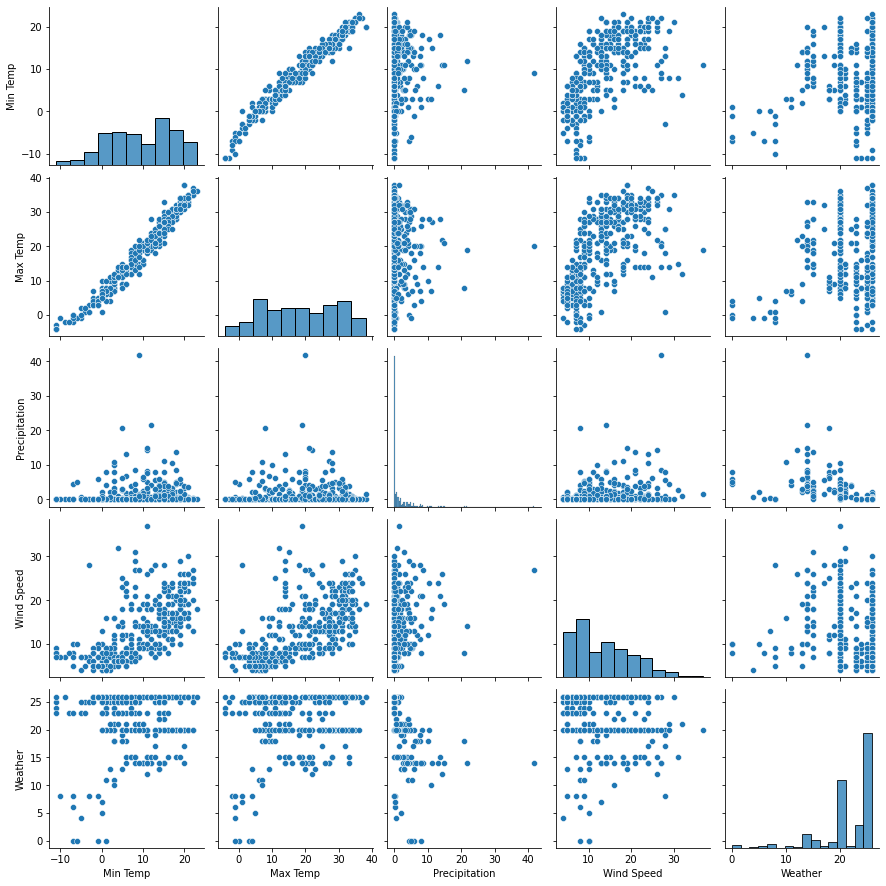

In [98]:
sns.pairplot(df24)

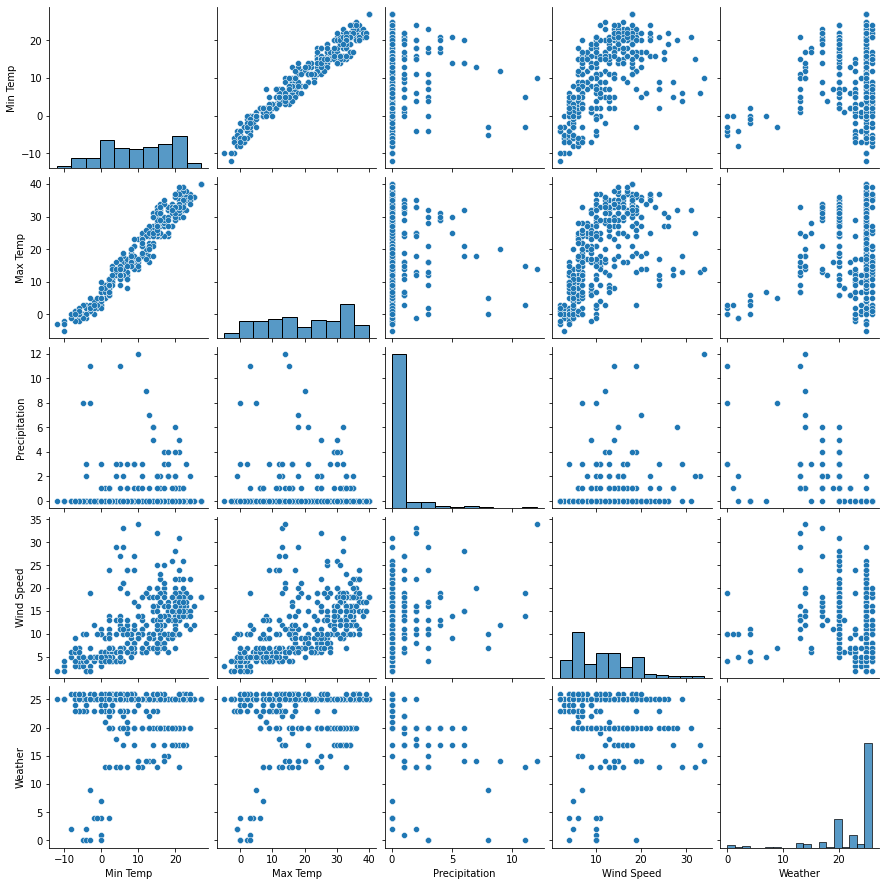

In [102]:
sns.pairplot(df21)

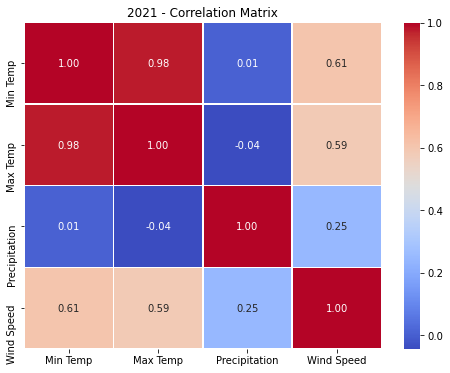

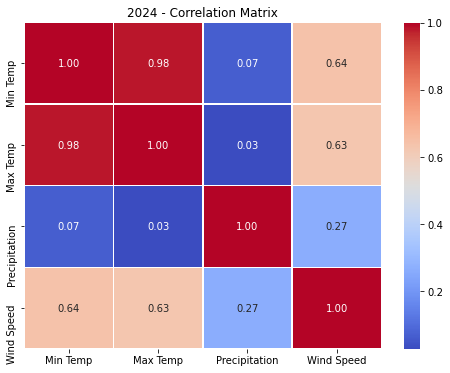

In [104]:
# Correlation matrix for each year
def plot_correlation_matrix(df, year):
    corr_matrix = df[['Min Temp', 'Max Temp', 'Precipitation', 'Wind Speed']].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(f'{year} - Correlation Matrix')
    plt.show()

# Plot correlation matrices for each year
plot_correlation_matrix(df21, 2021)
# plot_correlation_matrix(df22, 2022)
# plot_correlation_matrix(df23, 2023)
plot_correlation_matrix(df24, 2024)


***Conclusion:***
*Max Temp and Wind Speed are strongly connectesd. We will examine that later.*

In [105]:
# Perform ANOVA for each year on 'Min Temp'
groups_21 = df21['Min Temp']
groups_22 = df22['Min Temp']
groups_23 = df23['Min Temp']
groups_24 = df24['Min Temp']

f_stat, p_value = f_oneway(groups_21, groups_22, groups_23, groups_24)

f_stat, p_value

(1.4960689286830322, 0.21382590572679794)

*The F-statistic (1.496) is moderate and suggests some variation between the years, but it's not extreme.*

*The p-value (0.214) is above the typical threshold of 0.05, meaning there is no significant difference in the Min Temp between the years. In other words, the differences in Min Temp across the years are likely due to random variation, and we fail to reject the null hypothesis.*


***Conclusion:***
*Based on this result, one can conclude that there isn't enough statistical evidence to suggest that the average minimum temperatures significantly differ between the years 2021, 2022, 2023, and 2024. The Min Temp values across these years appear to be fairly similar when tested statistically.*

In [107]:
groups_21 = df21['Weather']
groups_22 = df22['Weather']
groups_23 = df23['Weather']
groups_24 = df24['Weather']

f_stat, p_value = f_oneway(groups_21, groups_22, groups_23, groups_24)

f_stat, p_value

(1.773216735904295, 0.1503399410004011)

*F-statistic (1.773): This tells you the ratio of the variance between the weather groups (across years) to the variance within each group (within each year). A higher F-statistic indicates more significant variation between the years in terms of weather conditions.*

*P-value (0.150): Since the p-value is greater than 0.05, it means that there is no statistically significant difference in the weather patterns between the years. The weather distribution across the years likely reflects random variation rather than any real difference.*

***Conclusion:***
*Since the p-value (0.150) is greater than 0.05, we fail to reject the null hypothesis. This means there is no significant difference in the weather patterns across the years 2021, 2022, 2023, and 2024. The variations in weather are not statistically significant when comparing the years.*

In [108]:
groups_21 = df21['Precipitation']
groups_22 = df22['Precipitation']
groups_23 = df23['Precipitation']
groups_24 = df24['Precipitation']

f_stat, p_value = f_oneway(groups_21, groups_22, groups_23, groups_24)

f_stat, p_value

(23.483328521909232, 7.628467089732035e-15)

*F-statistic (23.48): This is a high value, which indicates that there is substantial variation in precipitation between the years. It suggests that the mean precipitation across the different years is likely different, as there is a large variance between the group means compared to within-group variance.*

*P-value (7.63e-15): This is an extremely small p-value, much smaller than the typical significance threshold of 0.05. A p-value this small indicates that the differences in precipitation between the years are statistically significant. In other words, the variation in precipitation between the years is very unlikely to be due to random chance.*

***Conclusion:***
*Since the p-value (7.63e-15) is much smaller than 0.05, you reject the null hypothesis. This means there is a significant difference in precipitation across the years 2021, 2022, 2023, and 2024.
The high F-statistic (23.48) further supports that the differences in mean precipitation between the years are large and meaningful.*

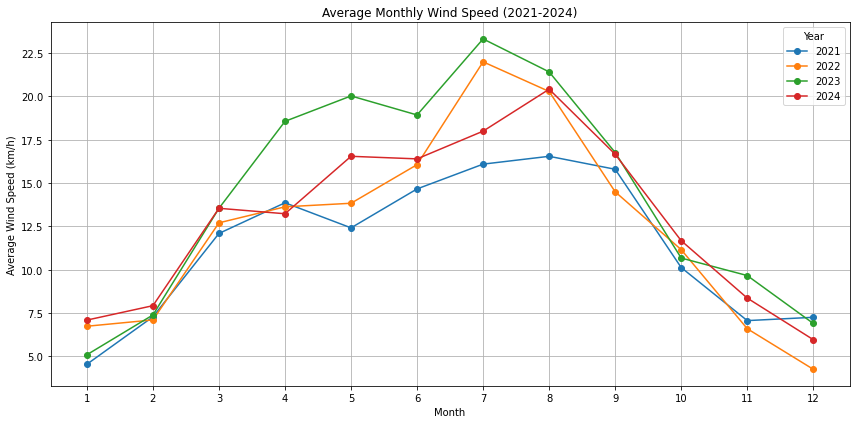

In [146]:
# Convert 'Date' column to datetime format for easier extraction of month
df21['Month'] = pd.to_datetime(df21['Date'], format='%m-%d').dt.month
df22['Month'] = pd.to_datetime(df22['Date'], format='%m-%d').dt.month
df23['Month'] = pd.to_datetime(df23['Date'], format='%m-%d').dt.month
df24['Month'] = pd.to_datetime(df24['Date'], format='%m-%d').dt.month

# Group by month and calculate average wind speed for each year
avg_wind_21 = df21.groupby('Month')['Wind Speed'].mean()
avg_wind_22 = df22.groupby('Month')['Wind Speed'].mean()
avg_wind_23 = df23.groupby('Month')['Wind Speed'].mean()
avg_wind_24 = df24.groupby('Month')['Wind Speed'].mean()

# Create a plot to compare the average wind speeds by month for each year
plt.figure(figsize=(12, 6))
plt.plot(avg_wind_21, label='2021', marker='o')
plt.plot(avg_wind_22, label='2022', marker='o')
plt.plot(avg_wind_23, label='2023', marker='o')
plt.plot(avg_wind_24, label='2024', marker='o')

plt.title('Average Monthly Wind Speed (2021-2024)')
plt.xlabel('Month')
plt.ylabel('Average Wind Speed (km/h)')
plt.legend(title='Year')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

***Conclusion***
*Wind speed is strongly correlated to summer days, i.e. higher temperatures*

<h3/>Climate Change & Extreme Weather Events<h3>


*Identify extreme weather events such as heatwaves and heavy rainfall. Count how many such events occurred in each year and analyze any trends over time.*

In [127]:
extreme_heat_21 = df21[df21['Max Temp'] > 35]  # Heatwave definition
extreme_rain_21 = df21[df21['Precipitation'] > 10] # Heavy rainfall definition
extreme_heat_22 = df22[df22['Max Temp'] > 35]  # Heatwave definition
extreme_rain_22 = df22[df22['Precipitation'] > 10] # Heavy rainfall definition
extreme_heat_23 = df23[df23['Max Temp'] > 35]  # Heatwave definition
extreme_rain_23 = df23[df23['Precipitation'] > 10] # Heavy rainfall definition
extreme_heat_24 = df24[df24['Max Temp'] > 35]  # Heatwave definition
extreme_rain_24 = df24[df24['Precipitation'] > 10] # Heavy rainfall definition

In [124]:
extreme_heat_21

,Date,Min Temp,Max Temp,Precipitation,Wind Speed,Weather
171,06-21,22,36,0,18,26
172,06-22,23,37,0,15,25
173,06-23,22,36,0,16,26
174,06-24,23,37,0,18,26
175,06-25,21,37,0,22,25
176,06-26,21,37,0,24,25
177,06-27,22,36,0,22,25
178,06-28,20,36,0,12,25
184,07-04,23,37,0,17,25
185,07-05,24,37,0,11,26


In [130]:
extreme_heat_24

,Date,Min Temp,Max Temp,Precipitation,Wind Speed,Weather
195,07-15,20,38,0.0,19,26
202,07-22,20,38,1.6,19,26
233,08-22,22,37,0.1,24,25
234,08-23,23,36,0.0,18,26
235,08-24,22,36,0.0,25,20


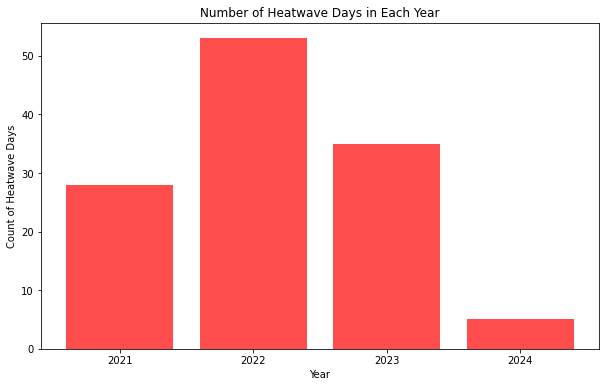

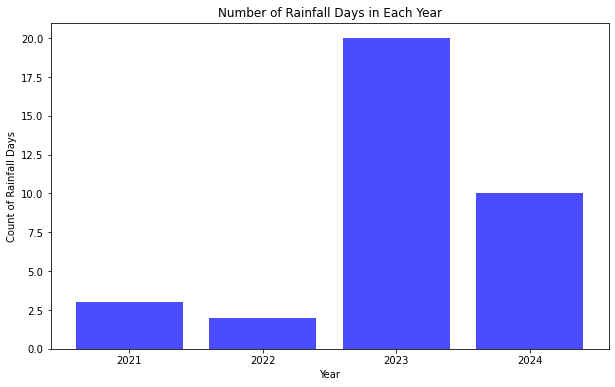

In [129]:
# Define the count of heatwave and rainfall days for each year
heatwave_counts = {
    '2021': len(extreme_heat_21),
    '2022': len(extreme_heat_22),
    '2023': len(extreme_heat_23),
    '2024': len(extreme_heat_24),
}

rainfall_counts = {
    '2021': len(extreme_rain_21),
    '2022': len(extreme_rain_22),
    '2023': len(extreme_rain_23),
    '2024': len(extreme_rain_24),
}

# Plot heatwave days histogram
plt.figure(figsize=(10, 6))
plt.bar(heatwave_counts.keys(), heatwave_counts.values(), color='red', alpha=0.7)
plt.title('Number of Heatwave Days in Each Year')
plt.xlabel('Year')
plt.ylabel('Count of Heatwave Days')
plt.show()

# Plot rainfall days histogram
plt.figure(figsize=(10, 6))
plt.bar(rainfall_counts.keys(), rainfall_counts.values(), color='blue', alpha=0.7)
plt.title('Number of Rainfall Days in Each Year')
plt.xlabel('Year')
plt.ylabel('Count of Rainfall Days')
plt.show()


*2021 and 2022: Both years experienced a significant number of heatwave days, especially 2022, which had the highest count. The increasing trend in heatwave days from 2021 to 2022 might suggest an exceptionally hot summer or anomalous weather patterns, which could be linked to global climate changes, regional heat events, or specific local factors like droughts or shifts in atmospheric pressure systems.
2023 and 2024: Both years saw a sharp decline in heatwave days, with 2024 having the lowest at just 5 days. This could indicate a cooler-than-usual period or a significant change in weather patterns.*


*2021 and 2022: Both of these years had very few rainfall days, suggesting a relatively dry period for Yerevan. This could be due to prolonged dry spells, drought conditions, or a lack of rain-generating weather systems.
2023 and 2024: The sharp increase in rainfall days in 2023 (20 days) compared to the previous years indicates a wetter year. This might reflect a change in the local climate or atmospheric conditions that favored more frequent rainfall, such as changes in wind patterns or increased moisture in the atmosphere. 2024 saw a moderate decrease compared to 2023, but still a relatively high count of 10 rainfall days, which could still be considered above average based on the earlier years.*

**Global Climate Change**

***Yerevan, like many places, is likely experiencing the effects of climate change. Warming temperatures may lead to more extreme heat events (reflected in 2022), but there could be variability between years due to changes in atmospheric circulation patterns or regional climate shifts. The warming might also influence precipitation patterns, making them less predictable.***